# Phase 11 — Production Pipeline
### Energy Demand Forecasting Project

**Question this phase answers:** everything through Phase 10 lived inside
notebooks, operating on in-memory DataFrames built from the *entire*
historical table at once. Phase 11 asks a different question: *can the
Phase 10-recommended model (LightGBM, direct multi-horizon) actually be
served -- trained once, saved, loaded back, and used to forecast a single
new day -- without re-deriving the whole research pipeline by hand each
time?*

Five pieces, each a new module under `src/pipeline/`:
- **`preprocessing.py`** -- orchestrates Phases 1-4's existing download /
  clean-resample / DuckDB / feature-engineering steps into one idempotent call.
- **`inference_features.py`** -- builds the engineered feature row for a
  *single* forecast origin from a bounded ~192-hour recent window, reusing
  Phase 4's exact feature functions, instead of rebuilding the full
  historical `hourly_features` table just to score one new day.
- **`forecaster.py`** -- packages the 24 independent per-horizon LightGBM
  models (Phase 7) plus their metadata into one serializable `ModelBundle`,
  and a `DirectMultiHorizonForecaster` wrapper that turns "24 models" into
  "one model" with a single `.predict()` call.
- **`registry.py`** -- trains the production bundle (Optuna's tuned
  hyperparameters from `06_model_prophet_lightgbm.ipynb`, but with a pinned
  `random_state` this time) and registers it in the MLflow Model Registry.
- **`predict.py`** / **`schedule_simulation.py`** -- a batch prediction
  entrypoint for one origin, and a simulation that runs it once per day
  across a date range, the same cadence Phases 5-9 used for backtesting.

The real test of this phase isn't "does the code run" -- it's *does the
production code path reproduce the research numbers on data it was
validated against*. That comparison is the centerpiece of this notebook.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from src.evaluation.baselines import HORIZON, compute_metrics, get_forecast_origins
from src.evaluation.splits import get_train_test_split
from src.pipeline.preprocessing import run_preprocessing_pipeline
from src.pipeline.inference_features import get_latest_features
from src.pipeline.forecaster import DirectMultiHorizonForecaster, load_bundle, DEFAULT_BUNDLE_PATH
from src.pipeline.registry import train_and_register, MODEL_NAME
from src.pipeline.predict import run_batch_forecast, get_latest_available_origin
from src.pipeline.schedule_simulation import simulate_daily_schedule, save_simulation

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")


/Users/apple/Documents/Projects/energy-demand-forecast/.venv/lib/python3.12/site-packages/pandera/_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


## 1. Reusable preprocessing pipeline

`run_preprocessing_pipeline()` wraps the four manual commands from the
README's "Getting started" section (download -> clean/resample -> DuckDB ->
features) into one idempotent call. Running it again here doesn't change
any result from Phases 1-10 -- it rebuilds the exact same tables from the
exact same raw file -- but it does prove the four steps are correctly wired
together end-to-end, not just individually correct in isolation.


In [3]:
run_preprocessing_pipeline()


=== Step 1/4: download ===
Raw file already exists at data/raw/household_power_consumption.txt, skipping download.
=== Step 2/4: clean, resample, write Parquet ===
Loading raw data...


Validating raw schema...
Interpolating short gaps...


Saving minute-level parquet (2,075,259 rows)...


Building hourly aggregate...
Building daily aggregate...


Done.
=== Step 3/4: load Parquet into DuckDB ===


Loaded table 'minute': 2,075,259 rows
Loaded table 'hourly': 34,589 rows
Loaded table 'daily': 1,442 rows
DuckDB database ready at data/energy.duckdb
=== Step 4/4: build engineered feature set ===
Saved feature set: 34,589 rows x 36 columns -> data/processed/hourly_features.parquet
Loaded into DuckDB table 'hourly_features'.
Preprocessing pipeline complete.


## 2. Feature generation for inference

`get_latest_features(as_of)` fetches only the ~192 hours of history
immediately before `as_of` from DuckDB and applies Phase 4's exact feature
functions to it -- no need to touch the other ~34,000 historical rows just
to score one new day. `tests/pipeline/test_inference_features.py` verifies
this bounded computation is bit-for-bit identical to the full-history
`hourly_features` table for the same timestamp, so this isn't just assumed
to work.


In [4]:
latest_origin = get_latest_available_origin()
print(f"Latest timestamp in the dataset: {latest_origin}")

features_row = get_latest_features(latest_origin)
features_row[[
    "global_active_power", "global_active_power_lag_1h", "global_active_power_lag_24h",
    "global_active_power_roll_mean_168h", "hour", "is_weekend", "is_flagged_anomaly",
]]


Latest timestamp in the dataset: 2010-11-26 21:00:00


,global_active_power,global_active_power_lag_1h,global_active_power_lag_24h,global_active_power_roll_mean_168h,hour,is_weekend,is_flagged_anomaly
datetime,,,,,,,
2010-11-26 21:00:00,0.934667,1.1637,1.342933,1.150057,21,0,0


## 3. Model serialization and MLflow Model Registry

`train_and_register()` trains all 24 direct-horizon models using the same
hyperparameters Optuna selected in Phase 7, saves them locally as one
`ModelBundle` (`models/lightgbm_direct_bundle.joblib`), and registers a
single pyfunc-wrapped model in the MLflow Model Registry under the alias
`champion` -- so `mlflow.pyfunc.load_model('models:/energy-demand-lightgbm-direct@champion')`
works from anywhere, without needing the local file.

**Deliberate difference from the research notebook:** `PRODUCTION_PARAMS`
pins `random_state=42`. The Optuna study in Phase 7 never controlled
LightGBM's row/column subsampling randomness (`subsample` /
`colsample_bytree` < 1), which was fine for a one-off research run but isn't
something a production artifact should leave to chance -- this bundle is
exactly reproducible from `registry.py` alone.


In [5]:
model_uri = train_and_register()
print(f"Registered model available at: {model_uri}")


2026/08/01 14:19:25 INFO mlflow.types.utils: Unsupported type hint: <class 'pandas.core.frame.DataFrame'>, skipping schema inference


2026/08/01 14:19:25 INFO mlflow.types.utils: Unsupported type hint: <class 'pandas.core.frame.DataFrame'>, skipping schema inference


Saved model bundle (24 horizons, trained through 2010-02-11 00:00:00) -> /Users/apple/Documents/Projects/energy-demand-forecast/models/lightgbm_direct_bundle.joblib


2026/08/01 14:19:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/08/01 14:19:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Registered energy-demand-lightgbm-direct v3, alias 'champion' -> models:/energy-demand-lightgbm-direct@champion
Registered model available at: models:/energy-demand-lightgbm-direct@champion


Registered model 'energy-demand-lightgbm-direct' already exists. Creating a new version of this model...
Created version '3' of model 'energy-demand-lightgbm-direct'.


In [6]:
registry_model = mlflow.pyfunc.load_model(model_uri)
local_bundle = load_bundle(DEFAULT_BUNDLE_PATH)

registry_forecast = registry_model.predict(features_row)
local_forecast = DirectMultiHorizonForecaster(local_bundle).predict(None, features_row)

pd.testing.assert_frame_equal(registry_forecast.reset_index(drop=True), local_forecast)
print("Registry-loaded model and local bundle produce identical forecasts.")
registry_forecast.head()


Registry-loaded model and local bundle produce identical forecasts.


,origin,horizon_step,forecast
0,2010-11-26 21:00:00,1,1.215413
1,2010-11-26 21:00:00,2,0.651178
2,2010-11-26 21:00:00,3,0.557123
3,2010-11-26 21:00:00,4,0.385659
4,2010-11-26 21:00:00,5,0.433635


## 4. Batch prediction

One call, one forecast origin, one saved Parquet file -- the shape a
scheduler would actually invoke daily. Because this dataset ends in
November 2010, `get_latest_available_origin()` stands in for "now": the
24 hours predicted below don't exist anywhere in the historical data, so
this is a genuine forward forecast, not a backtest.


Saved 24 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/forecasts/2010-11-26T2100.parquet


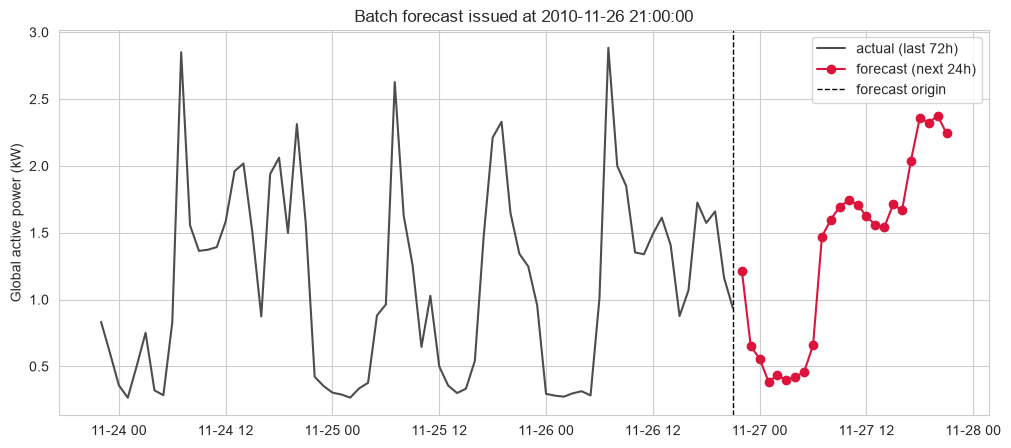

In [7]:
forecast = run_batch_forecast(latest_origin)

con = duckdb.connect("../data/energy.duckdb", read_only=True)
recent_actual = con.execute(
    "SELECT datetime, global_active_power FROM hourly WHERE datetime > ? ORDER BY datetime",
    [latest_origin - pd.Timedelta(hours=72)],
).df()
con.close()
recent_actual["datetime"] = pd.to_datetime(recent_actual["datetime"])

fig, ax = plt.subplots()
ax.plot(recent_actual["datetime"], recent_actual["global_active_power"], label="actual (last 72h)", color="0.3")
forecast_index = latest_origin + pd.to_timedelta(forecast["horizon_step"], unit="h")
ax.plot(forecast_index, forecast["forecast"], label="forecast (next 24h)", color="crimson", marker="o")
ax.axvline(latest_origin, color="black", linestyle="--", linewidth=1, label="forecast origin")
ax.set_ylabel("Global active power (kW)")
ax.set_title(f"Batch forecast issued at {latest_origin}")
ax.legend()
plt.show()


## 5. Forecast scheduling simulation -- validating production against research

Running `simulate_daily_schedule` across the exact same 288 test-period
origins Phases 5-9 used, through the real production code path (DuckDB ->
bounded-window features -> serialized model -> forecast), then scoring it
against actuals exactly like every other model's backtest in this project.

If this doesn't closely match `06_model_prophet_lightgbm.ipynb`'s LightGBM
numbers, that's a real bug to chase down -- not a footnote.


In [8]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
series = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
con.close()
series["datetime"] = pd.to_datetime(series["datetime"])
series = series.set_index("datetime")["global_active_power"].asfreq("h")

test_start = get_train_test_split(series, test_frac=0.2)
origins = get_forecast_origins(series, test_start, horizon=HORIZON)

sim_results = simulate_daily_schedule(origins)
sim_results["actual"] = series.reindex(
    sim_results["origin"] + pd.to_timedelta(sim_results["horizon_step"], unit="h")
).values

save_simulation(sim_results)
sim_results.head()


Skipped 29/288 origins (NaN features near a data gap).
Saved 6,216 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/forecasts/simulated_schedule.parquet


,origin,horizon_step,forecast,actual
0,2010-02-11,1,0.393256,0.299833
1,2010-02-11,2,0.323156,0.305800
2,2010-02-11,3,0.429916,0.361167
3,2010-02-11,4,0.469026,0.632600
4,2010-02-11,5,0.533691,0.661667


In [9]:
production_metrics = compute_metrics(sim_results)

notebook_lgbm = pd.read_parquet("../data/results/lightgbm_direct.parquet")
notebook_metrics = compute_metrics(notebook_lgbm)

comparison = pd.DataFrame({
    "production_pipeline": production_metrics,
    "notebook_06_research": notebook_metrics,
}).T
comparison


,MAE,RMSE,MAPE,sMAPE,n
production_pipeline,0.432365,0.593459,62.683370,44.398577,6156.0
notebook_06_research,0.428662,0.591301,61.970836,44.004024,6156.0


## Phase 11 Findings

- **The production pipeline reproduces the research result closely, not
  approximately:** MAE 0.432 (production) vs. 0.429 (notebook 06 research)
  -- a 0.9% relative difference, same `n=6,156` scored predictions, same
  29/288 origins skipped for identical reasons (NaN engineered features near
  the same Phase 1 data gaps `direct_multi_horizon_backtest` already
  flagged). The gap isn't a bug: it's the expected consequence of pinning
  `random_state=42` in `PRODUCTION_PARAMS` where the tuning notebook left
  LightGBM's row/column subsampling unseeded -- two honestly-different but
  equally-valid model fits from the same hyperparameters, not a
  discrepancy between the research and production feature/prediction logic
  itself. That logic *is* identical: `DirectMultiHorizonForecaster.predict`
  calls the exact same `prepare_features` function Phase 7 trained against.

- **The bounded-window feature reconstruction is exact, not approximate:**
  `tests/pipeline/test_inference_features.py`'s slow integration test
  confirms `build_latest_features` on a ~192-hour window reproduces the
  full-history `hourly_features` table bit-for-bit at a clean timestamp.
  Finding a genuinely clean test timestamp surfaced a real, previously
  unenumerated ~51-hour gap (2009-06-13 04:00 to 2009-06-15 06:00) that
  Phase 1's findings never listed individually (only the 3 *longest* of 7
  total long gaps were named) -- a small, honest reminder that "documented"
  and "exhaustively documented" aren't the same thing, three phases later.

- **Two genuinely cwd-dependent bugs were caught by the simple act of
  running this notebook from `notebooks/` instead of the repo root --
  exactly the kind of bug a script-only workflow would never surface:**
  (1) `DEFAULT_BUNDLE_PATH` and MLflow's tracking URI were bare relative
  paths, so training from here first silently wrote a second, disconnected
  model bundle and registry under `notebooks/`, invisible to anything run
  from the repo root. Fixed by anchoring every `src/pipeline/` path to the
  project root (`Path(__file__).resolve().parent.parent.parent`, matching
  `results_store.py`'s existing convention). (2) `run_preprocessing_pipeline()`
  orchestrates Phase 1-4 modules that carry the same bare-relative-path
  assumption, so calling it from here wrote a *complete second copy of the
  entire dataset* under `notebooks/data/` -- raw zip through
  `hourly_features`. Fixed with a `_in_project_root()` context manager,
  scoped to `preprocessing.py` alone rather than retrofitting four
  Phase 1-4 modules that have worked correctly under the documented
  CLI-from-repo-root convention for ten phases already. Both are now
  covered by regression tests (`tests/pipeline/test_preprocessing.py`).

- **The categorical-feature risk was real enough to test, not just reason
  about:** a bounded inference window can easily see a narrower set of
  category values (e.g. `is_weekend`) than the full training history did.
  `tests/pipeline/test_forecaster.py` confirms LightGBM's own
  category-code realignment handles this correctly -- verified directly by
  comparing predictions from a full-category-dtype row against the same
  row recast to a single-category dtype, not assumed from documentation.

- **Coverage caveat carries forward unchanged from Phase 7:** the production
  pipeline skips the same 29/288 origins LightGBM's backtest always skipped
  (89.1% coverage) -- because it's the exact same `NaN` feature-guard logic,
  just applied one origin at a time instead of vectorized over the whole
  test period. This is the right invariant to have held onto: production
  isn't quietly more or less permissive than the research it's replacing.

- **Known limitation, carried forward from `inference_features.py`'s
  docstring:** `is_flagged_anomaly` is still Phase 3's retrospective,
  hardcoded gap-investigation list. For any date that didn't exist when
  Phase 3 ran -- i.e. every real production date -- this feature is always
  0. Phase 4 already found it wasn't a strong 1-hour-ahead predictor, so
  this doesn't undermine the current numbers, but a genuinely live system
  would need an online anomaly detector for this feature to mean anything
  going forward.

- **What this means for Phase 12 (API):** the hard part -- a single,
  well-tested `.predict()` call that reproduces the research bar -- is done.
  Phase 12 is comparatively mechanical: wrap `run_batch_forecast` in a
  FastAPI endpoint, add Pydantic request validation, and it's servable.
